In [ ]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import yfinance as yf
import streamlit as st
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")
client = StockHistoricalDataClient(ALPACA_KEY,  ALPACA_SECRET)

In [9]:
START_DATE = "2016-01-01"
END_DATE = datetime.now()
SYMBOL = "SPY"

params = StockBarsRequest(
    symbol_or_symbols=SYMBOL,
    timeframe=TimeFrame.Day,
    start=START_DATE,
    end=END_DATE,
    feed="iex",
    adjustment="all"
)

df = client.get_stock_bars(params).df
df = df.reset_index()
df = df[df["symbol"] == SYMBOL].set_index("timestamp")
df.index = df.index.tz_localize(None)

In [24]:
class SMA_Backtest:
    
    def  __init__(self, df: pd.DataFrame, short: bool = False):
        self.df = df.copy()
        self.short = short
        self.results = None
        
    def add_sma(self, short_window : int = 50, long_window : int = 200) -> None:
        self.df[f"SMA_{short_window}"] = self.df["close"].rolling(window = short_window).mean()
        self.df[f"SMA_{long_window}"]  = self.df["close"].rolling(window = long_window).mean()
        self.short_window = short_window
        self.long_window = long_window
        
    def run(self):
        df = self.df.dropna(subset=[f"SMA_{self.short_window}", f"SMA_{self.long_window}"]).copy()
        
        df["signal"] = np.where(df[f"SMA_{self.short_window}"] > df[f"SMA_{self.long_window}"], 1, -1 if self.short else 0)
        df["position"] = df["signal"].shift(1)
        df["market_return"] = df["close"].pct_change()
        df["strategy_return"] = df["market_return"] * df["position"]
        df["equity_curve"] = (1 + df["strategy_return"]).cumprod()
        df["buy_hold"] = (1 + df["market_return"]).cumprod()  # ← calculated on trimmed df, same start date
        
        self.results = df
        return df
    
    def metrics(self) -> dict:
        r = self.results["strategy_return"]
        equity = self.results["equity_curve"]
        
        return {
            "Total Return": equity.iloc[-1] - 1,
            "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,
            "Max Drawdown": ((equity - equity.cummax()) / equity.cummax()).min(),
            "equity_curve": equity
        }
    
    def plot(self) -> None:
        
        plt.figure(figsize=(12, 6))
        plt.plot(self.results.index, self.results["close"], label="SPY", linewidth=1)
        plt.plot(self.results.index, self.results[f"SMA_{self.short_window}"], label=f"SMA {self.short_window}")
        plt.plot(self.results.index, self.results[f"SMA_{self.long_window}"], label=f"SMA {self.long_window}")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(12, 5))
        plt.plot(self.results.index[self.long_window:], self.results["equity_curve"][self.long_window:], label="SMA Crossover")
        plt.plot(self.results.index[self.long_window:], self.results["buy_hold"][self.long_window:], label="Buy & Hold")
        plt.legend()
        plt.title("Strategy vs Buy & Hold")
        plt.tight_layout()
        plt.show()

{'Total Return': np.float64(0.6915618249095774), 'Sharpe Ratio': np.float64(0.8685969634915027), 'Max Drawdown': np.float64(-0.1873706860878918)}


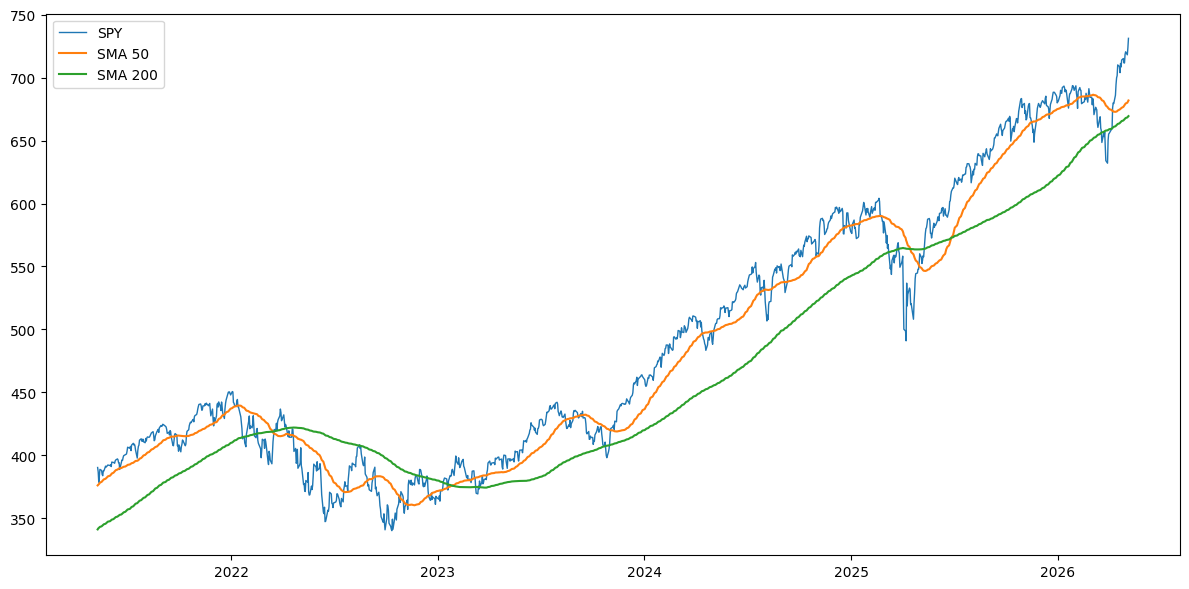

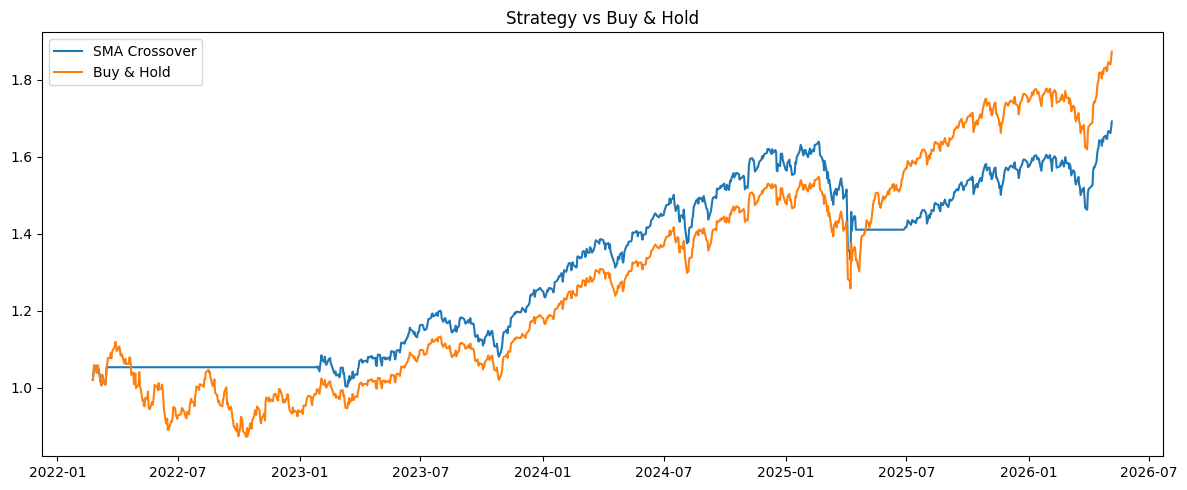

In [11]:
bt = SMA_Backtest(df, short=False)
bt.add_sma(50, 200)
bt.run()
print(bt.metrics())
bt.plot()

In [39]:
short_windows = range(10, 100, 10)
long_windows  = range(50, 250, 10)

results_normal = []
results_shorting = []

for sw in short_windows:
    
    for lw in long_windows:
        
        bt = SMA_Backtest(df, short=False)
        bt.add_sma(sw, lw)
        bt.run()
        m = bt.metrics()
        
        results_normal.append({
            "short_window": sw,
            "long_window": lw,
            "total_return": m["Total Return"],
            "sharpe": m["Sharpe Ratio"],
            "max_drawdown": m["Max Drawdown"],
            "equity_curve" : m["equity_curve"]
        })

normal_df = pd.DataFrame(results_normal)

for sw in short_windows:
    
    for lw in long_windows:
        
        bt = SMA_Backtest(df, short=True)
        bt.add_sma(sw, lw)
        bt.run()
        m = bt.metrics()
        
        results_shorting.append({
            "short_window": sw,
            "long_window": lw,
            "total_return": m["Total Return"],
            "sharpe": m["Sharpe Ratio"],
            "max_drawdown": m["Max Drawdown"],
            "equity_curve" : m["equity_curve"]
        })

short_df = pd.DataFrame(results_shorting)
        

/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_57083/3292963511.py:33: RuntimeWarning: invalid value encountered in scalar divide
  "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,
/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_57083/3292963511.py:33: RuntimeWarning: invalid value encountered in scalar divide
  "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,
/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_57083/3292963511.py:33: RuntimeWarning: invalid value encountered in scalar divide
  "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,
/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_57083/3292963511.py:33: RuntimeWarning: invalid value encountered in scalar divide
  "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,
/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_57083/3292963511.py:33: RuntimeWarning: invalid value encountered in scalar divide
  "Sharpe Ratio": (r.mean() / r.std()) * np.sqrt(252) ,


In [31]:
results_df.head()

,short_window,long_window,total_return,sharpe,max_drawdown,equity_curve
0,10,50,0.696404,0.891964,-0.127343,timestamp 2020-10-02 04:00:00 NaN 2020...
1,10,60,0.435387,0.633051,-0.215181,timestamp 2020-10-16 04:00:00 NaN 2020...
2,10,70,0.602623,0.807685,-0.219998,timestamp 2020-10-30 04:00:00 NaN 2020...
3,10,80,0.710375,0.916299,-0.203194,timestamp 2020-11-13 05:00:00 NaN 2020...
4,10,90,0.780303,0.987296,-0.209486,timestamp 2020-11-30 05:00:00 NaN 2020...


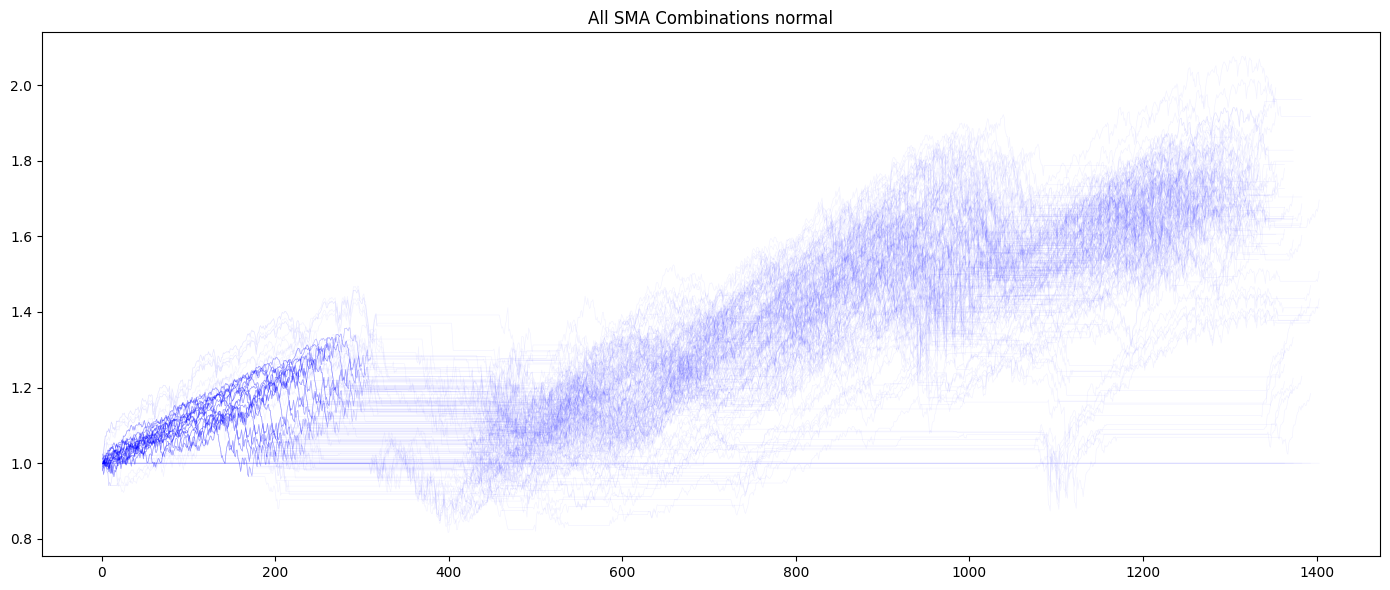

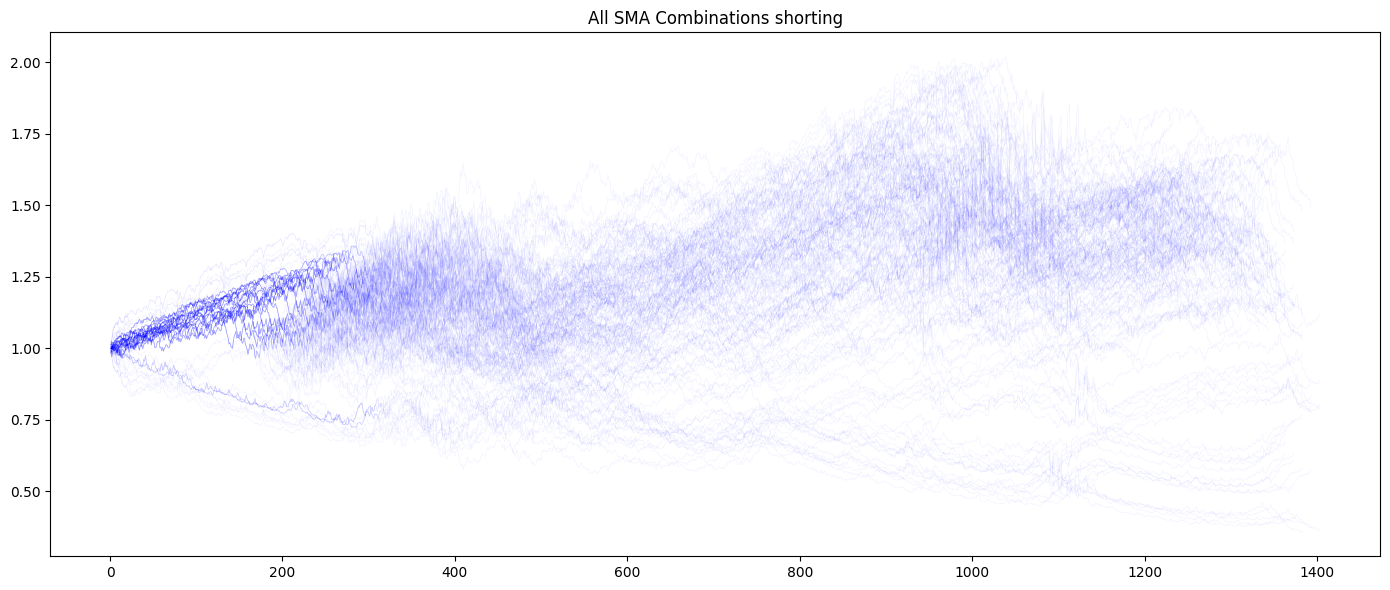

In [45]:
plt.figure(figsize=(14, 6))
for r in results_normal:
    plt.plot(r["equity_curve"].values, alpha=0.05, color="blue", linewidth=0.5)

plt.title("All SMA Combinations normal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for r in results_shorting:
    plt.plot(r["equity_curve"].values, alpha=0.05, color="blue", linewidth=0.5)

plt.title("All SMA Combinations shorting")
plt.tight_layout()
plt.show()


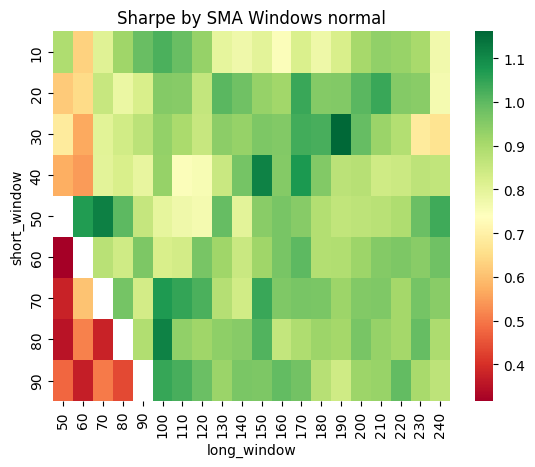

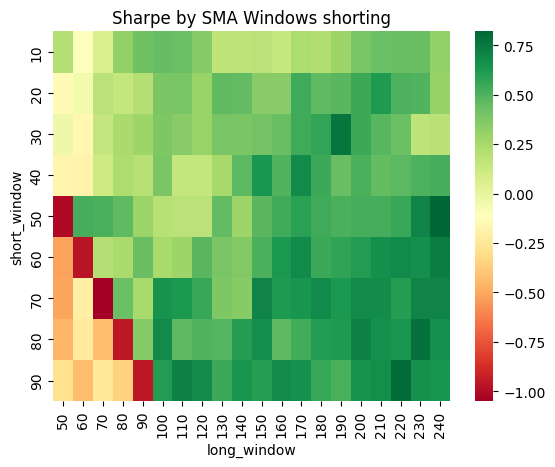

In [44]:
pivot = normal_df.pivot(index="short_window", columns="long_window", values="sharpe")
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="RdYlGn")
plt.title("Sharpe by SMA Windows normal")
plt.show()

pivot = short_df.pivot(index="short_window", columns="long_window", values="sharpe")
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="RdYlGn")
plt.title("Sharpe by SMA Windows shorting")
plt.show()